<a href="https://colab.research.google.com/github/JorgeEVC/Unimodal-Model-for-Emotion-Detection-in-IVLEs-Using-Spatial-Analysis-of-Hands-and-Head/blob/main/IEEE_Medianas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Montaje del drive y R

In [ ]:
%load_ext rpy2.ipython

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Instalación de paquetes y librerias

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

In [ ]:
!pip install --quiet optuna
import optuna
from sklearn.model_selection import cross_val_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.1 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import classification_report

# Random Forest en Valencia

Del análisis de los componentes que explicaran más del 80% de la varianza, se determinan como variables útiles:

* **H_RealRoll, H_roll, H_RealPitch, H_pitch, H_Real_yaw, H_yaw, L_RealYaw, L_yaw, L_RealPitch, L_pitch, R_RealRoll, R_roll, R_RealPitch, R_pitch, R_RealYaw, R_yaw, H_ky, H_kz, AH_ky, L_ky, AL_ky, L_kx, L_kz, R_kz, R_ky**

Se lee la tabla *_redux_val* en el dataframe *Tabla* y se separan los valores de entrada y salida.

In [ ]:
Tabla=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_Mediana_redux_val.xlsx")
x=Tabla.drop(["Val", "ValCat"], axis=1)
y=Tabla["Val"]
x.head()

,H_RealRoll,H_roll,H_RealPitch,H_pitch,H_RealYaw,H_yaw,L_RealYaw,L_yaw,L_RealPitch,L_pitch,...,R_yaw,H_ky,H_kz,AH_ky,L_ky,AL_ky,L_kx,L_kz,R_kz,R_ky
0,3.618897,1.488255,21.390385,21.390385,189.941500,189.941500,178.68780,178.687800,22.82165,18.986365,...,169.976300,6.013443,7.197476,5.221200,-17.039905,-17.008185,1.900343,5.333543,1.666173,-5.797496
1,5.192762,1.998445,36.943790,36.306980,69.891530,3.707715,259.66260,-6.116455,19.98433,15.611220,...,-5.979279,10.301880,-1.948685,11.444081,-3.333527,-1.559042,-5.840093,-1.659805,0.189474,-8.592635
2,6.490438,0.531204,21.014580,20.450060,186.306000,186.306000,197.41450,197.414500,13.13554,11.404520,...,166.279200,20.270020,10.100700,8.715729,-3.650442,-3.396486,0.000000,-1.207242,3.559774,18.885760
3,5.033614,1.094947,18.454940,17.408490,133.426800,127.946700,99.11899,98.912080,22.12996,21.432850,...,133.320500,35.662060,-0.958770,29.980786,-2.512781,-2.508936,-14.997960,0.161993,-6.736479,7.203727
4,348.911150,-0.270020,20.383760,19.011150,95.367565,91.144485,112.20925,101.894500,25.96578,6.023143,...,73.056995,-19.049275,-1.083630,-8.616301,-17.657725,-17.659872,0.279486,-5.420906,0.075741,-2.415090


In [ ]:
y.head()

,Val
0,0.954308
1,0.954561
2,0.697022
3,0.716641
4,0.723382


Se separan las muestras de entrenamiento y prueba en 80/20.

Se utiliza un Random forest con los metaparametros Default.

En la variable *regressor*  se guarda el modelo entrenado y se prueba con el 20% de x_test.

Al final se obtiene el ECM.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=0)

In [ ]:
rf_reg = RandomForestRegressor (random_state=42)
regressor = rf_reg.fit(x_train, y_train)
y_pred = regressor.predict(x_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(y_test, y_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(y_test, y_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("Coeficiente de Determinación", metrics.r2_score(y_test, y_pred))

Error Cuadrático Medio 0.043405942775334154
Error Absoluto Medio 0.16521545867096774
Raíz del Error Cuadrático Medio 0.20834092918899577
Coeficiente de Determinación -0.020239258991134212


La primera aproximación con el dataset original con los hyperparámetros en default, arrojan un ECM de 0.04340

## SMOTE en valencia

Para realizar el balanceo de los datos, primero se categorizan los datos de valencia en 1=muy bajo, 2=bajo, 3=medio, 4=alto y 5=muy alto. El *y_smote* recoge la columna de valencia categorizada.

In [ ]:
df_smote=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_Mediana_redux_val.xlsx")
x_smote=df_smote.filter(items=["H_RealRoll", "H_roll", "H_RealPitch", "H_pitch", "H_RealYaw", "H_yaw", "L_RealYaw", "L_yaw", "L_RealPitch", "L_pitch", "R_RealRoll", "R_roll", "R_RealPitch", "R_pitch", "R_RealYaw", "R_yaw", "H_ky", "H_kz", "AH_ky", "L_ky", "AL_ky", "L_kx", "L_kz", "R_kz", "R_ky", "Val"])
y_smote=df_smote["ValCat"]

print('Original dataset shape %s' % Counter(y_smote))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x_smote, y_smote)
print('Resampled dataset shape %s' % Counter(y_res))

Original dataset shape Counter({5: 279, 4: 131, 3: 41, 1: 7, 2: 6})
Resampled dataset shape Counter({5: 279, 4: 279, 3: 279, 2: 279, 1: 279})


El data set para valencia pasa de 464 a 1395 observaciones, abarcando las 5 categorias.

##Random Forest con los datos de SMOTE

In [ ]:
Nx=X_res.drop(["Val"], axis=1)
Ny=X_res["Val"]
Nx_train, Nx_test, Ny_train, Nyv_test = train_test_split(Nx,Ny,test_size=0.20, random_state=0)

In [ ]:
rf_reg2 = RandomForestRegressor (random_state=42)
regressor2 = rf_reg2.fit(Nx_train, Ny_train)
Nyv_pred = regressor2.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.020583116149516644
Error Absoluto Medio 0.08824617091521814
Raíz del Error Cuadrático Medio 0.143468171207124
Coeficiente de Determinación 0.781223663000748


En este punto se tiene un modelo en la variable *regressor2* para la variable Valencia entrenada con datos SMOTE. Además puede apreciarse que con dichos datos se obtuvo un ECM menor al original (0.04340 > 0.02058).


In [ ]:
regressor2.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

##Optimización de hyperparametros con GridSearchCV

Ahora se busca mejorar los hyperparametros y refinar el modelo. En esta sección se usa el param_grid y GridSearchCV para generar opciones de combinación y probarlas.

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [10, 20, 30, 40],
    'max_features': [1, 2, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 5, 7, 10],
    'n_estimators': [30, 50, 100, 300]
}

In [ ]:
rfr_cv = GridSearchCV(estimator = rf_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfr_cv.fit(Nx_train, Ny_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [10, 20, 30, 40],
                         'max_features': [1, 2, 10, 20],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 5, 7, 10],
                         'n_estimators': [30, 50, 100, 300]},
             scoring='neg_mean_squared_error')

In [ ]:
rfr_cv.best_params_

{'bootstrap': True,
 'max_depth': 20,
 'max_features': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
Nyv_pred = rfr_cv.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.017338222341535797
Error Absoluto Medio 0.08465575244541435
Raíz del Error Cuadrático Medio 0.13167468375331606
Coeficiente de Determinación 0.8157133863305304


con un ECM 0.0205 > 0.01733, estos parametros no son del todo mejores que el default.

Usando los resultados se define un nuevo param_grid

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [10, 15, 25, 30],
    'max_features': [5, 10, 13, 15],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [3, 4, 5, 6],
    'n_estimators': [110, 150, 200, 250]
}

In [ ]:
rfr_cv = GridSearchCV(estimator = rf_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfr_cv.fit(Nx_train, Ny_train)

In [ ]:
rfr_cv.best_params_

{'bootstrap': True,
 'max_depth': 25,
 'max_features': 4,
 'min_samples_leaf': 2,
 'min_samples_split': 3,
 'n_estimators': 200}

In [ ]:
Nyv_pred = rfr_cv.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.01653456496168671
Error Absoluto Medio 0.08822304218739312
Raíz del Error Cuadrático Medio 0.12858679932903966
Coeficiente de Determinación 0.8242553979719468


Con un ECM de 0.01653 los nuevos parametros mejoran la prueba.

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [26, 27, 28, 29],
    'max_features': [4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'n_estimators': [100, 150, 200, 250]
}

In [ ]:
rfr_cv = GridSearchCV(estimator = rf_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfr_cv.fit(Nx_train, Ny_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [26, 27, 28, 29],
                         'max_features': [4, 6, 8, 10],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [100, 150, 200, 250]},
             scoring='neg_mean_squared_error')

In [ ]:
rfr_cv.best_params_

{'bootstrap': True,
 'max_depth': 28,
 'max_features': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
Nyv_pred = rfr_cv.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.014846324379989373
Error Absoluto Medio 0.07944725579692562
Raíz del Error Cuadrático Medio 0.12184549388462985
Coeficiente de Determinación 0.8421995755082479


En esta última interación con GRdSearchCV los resultados mejoran (0.0148 < 0.1653).

##Optimización de hyperparametros con Optuna

A continuación se utiliza una aproximación con Optuna para buscar mejores hyperparametros a los encontrados con GridSearchCV.

Se utilizan los resultados anteriores para diseñar el study de optuna y se itera varias veces ajustando los parametros del estudio de acuerdo a los resultados de cada estudio previo. Las celdas siguientes presentan la última iteración.

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 253,283)
    max_depth = trial.suggest_int('max_depth', 17, 25)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 1)
    max_features = trial.suggest_int('max_features', 4, 6, step=2)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features)

    score = cross_val_score(model, Nx_train, Ny_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    return score

In [ ]:
study = optuna.create_study(study_name='Valencia', direction='maximize', sampler=optuna.samplers.RandomSampler(seed=32))

[I 2025-08-21 17:43:45,112] A new study created in memory with name: Valencia


In [ ]:
study.optimize(objective, n_trials=500)

[I 2025-08-21 17:44:11,801] Trial 0 finished with value: -0.015040517597875142 and parameters: {'n_estimators': 279, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 6}. Best is trial 0 with value: -0.015040517597875142.
[I 2025-08-21 17:44:32,789] Trial 1 finished with value: -0.01529279661933671 and parameters: {'n_estimators': 282, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 6}. Best is trial 0 with value: -0.015040517597875142.
[I 2025-08-21 17:44:51,149] Trial 2 finished with value: -0.01512284733140865 and parameters: {'n_estimators': 256, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 6}. Best is trial 0 with value: -0.015040517597875142.
[I 2025-08-21 17:45:05,908] Trial 3 finished with value: -0.01492288925044204 and parameters: {'n_estimators': 271, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}. Best is trial 3 with value: -0.014922889250442

In [ ]:
study.best_params

{'n_estimators': 256,
 'max_depth': 18,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 6}

In [ ]:
bestParams = study.best_params

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_slice(study, params=['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features'])

In [ ]:
best_n_estimators = bestParams['n_estimators']
best_max_depth = bestParams['max_depth']
best_min_samples_split = bestParams['min_samples_split']
best_min_samples_leaf = bestParams['min_samples_leaf']
best_max_features = bestParams['max_features']

In [ ]:
best_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    random_state=39)

In [ ]:
best_model.fit(Nx_train, Ny_train)

RandomForestRegressor(max_depth=18, max_features=6, n_estimators=256,
                      random_state=39)

In [ ]:
Nyv_pred = best_model.predict(Nx_test)
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.01631340879351342
Error Absoluto Medio 0.0827087907725053
Raíz del Error Cuadrático Medio 0.12772395544107384
Coeficiente de Determinación 0.8266060496432623


## Best hyperparameters

Este ultimo paso explora una sección del espacio solución combinando los parametros señalados. Tras repetir varias veces el procedimiento se obtuvieron los valores utilizados en el siguiente bloque de código como los mejores.

In [ ]:
fix_reg = RandomForestRegressor (n_estimators=300, max_depth=17, min_samples_split=2, min_samples_leaf=1, max_features=4, random_state=32) #ECM 0.015695 CD 0.8331 CV10
fix_regressor = fix_reg.fit(Nx_train, Ny_train) #Nombre del modelo: fix_regressor
Nyv_pred = fix_regressor.predict(Nx_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nyv_test, Nyv_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nyv_test, Nyv_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nyv_test, Nyv_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nyv_test, Nyv_pred))

Error Cuadrático Medio 0.01569523471473163
Error Absoluto Medio 0.08216082983591191
Raíz del Error Cuadrático Medio 0.1252806238599235
Coeficiente de Determinación 0.8331765737369595


# Random Forest de Activacion

Se lee la tabla Tejalpa_Mediana_redux_Act en el dataframe *Tabla* y se separan los valores de entrada y salida.

In [ ]:
Tabla2=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_Mediana_redux_Act.xlsx")
x2=Tabla2.drop(["Act", "ActCat"], axis=1)
y2=Tabla2["Act"]
x2.head()

,H_RealRoll,H_roll,H_RealPitch,H_pitch,H_RealYaw,H_yaw,L_RealYaw,L_yaw,L_RealPitch,L_pitch,...,R_yaw,H_ky,H_kz,AH_ky,L_ky,AL_ky,L_kx,L_kz,R_kz,R_ky
0,3.618897,1.488255,21.390385,21.390385,189.941500,189.941500,178.68780,178.687800,22.82165,18.986365,...,169.976300,6.013443,7.197476,5.221200,-17.039905,-17.008185,1.900343,5.333543,1.666173,-5.797496
1,5.192762,1.998445,36.943790,36.306980,69.891530,3.707715,259.66260,-6.116455,19.98433,15.611220,...,-5.979279,10.301880,-1.948685,11.444081,-3.333527,-1.559042,-5.840093,-1.659805,0.189474,-8.592635
2,6.490438,0.531204,21.014580,20.450060,186.306000,186.306000,197.41450,197.414500,13.13554,11.404520,...,166.279200,20.270020,10.100700,8.715729,-3.650442,-3.396486,0.000000,-1.207242,3.559774,18.885760
3,5.033614,1.094947,18.454940,17.408490,133.426800,127.946700,99.11899,98.912080,22.12996,21.432850,...,133.320500,35.662060,-0.958770,29.980786,-2.512781,-2.508936,-14.997960,0.161993,-6.736479,7.203727
4,348.911150,-0.270020,20.383760,19.011150,95.367565,91.144485,112.20925,101.894500,25.96578,6.023143,...,73.056995,-19.049275,-1.083630,-8.616301,-17.657725,-17.659872,0.279486,-5.420906,0.075741,-2.415090


In [ ]:
y2.head()

,Act
0,0.958422
1,0.500000
2,0.924485
3,0.698892
4,0.506945


In [ ]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2,y2,test_size=0.20, random_state=0)

In [ ]:
rf_reg2 = RandomForestRegressor (random_state=42)
regressor2act = rf_reg2.fit(x2_train, y2_train)
y2_pred = regressor2act.predict(x2_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(y2_test, y2_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(y2_test, y2_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(y2_test, y2_pred)))
print("Coeficiente de Determinación", metrics.r2_score(y2_test, y2_pred))

Error Cuadrático Medio 0.045552907679273606
Error Absoluto Medio 0.17907076737741934
Raíz del Error Cuadrático Medio 0.21343127155895783
Coeficiente de Determinación 0.010624599350385955


Se obtienen con el regresor RF default un ECM de 0.0455.

##SMOTE en categoria Activación

Para el SMOTE en Activación se usa la tabla Tejalpa_Medianas_redux_Act. Esta vez, la variable que se recoge para *y_smote* es la que corresponde a Activación.

In [ ]:
dfa_smote=pd.read_excel("/content/drive/MyDrive/Datos V2/Tejalpa_Mediana_redux_Act.xlsx")
xa_smote=dfa_smote.filter(items=["H_RealRoll", "H_roll", "H_RealPitch", "H_pitch", "H_RealYaw", "H_yaw", "L_RealYaw", "L_yaw", "L_RealPitch", "L_pitch", "R_RealRoll", "R_roll", "R_RealPitch", "R_pitch", "R_RealYaw", "R_yaw", "H_ky", "H_kz", "AH_ky", "L_ky", "AL_ky", "L_kx", "L_kz", "R_kz", "R_ky", "Act"])
ya_smote=dfa_smote["ActCat"]
print('Original dataset shape %s' % Counter(ya_smote))

sma = SMOTE(random_state=42)
Xa_res, ya_res = sma.fit_resample(xa_smote, ya_smote)
print('Resampled dataset shape %s' % Counter(ya_res))

Original dataset shape Counter({5: 204, 4: 139, 3: 104, 1: 10, 2: 7})
Resampled dataset shape Counter({5: 204, 3: 204, 4: 204, 1: 204, 2: 204})


En este caso con SMOTE se pasa de 464 a 1020 observaciones.

##Random Forest con los datos de SMOTE

In [ ]:
Nxa=Xa_res.drop(["Act"], axis=1)
Nya=Xa_res["Act"]
Nxa_train, Nxa_test, Nya_train, Nya_test = train_test_split(Nxa,Nya,test_size=0.20, random_state=0)

In [ ]:
rfa_reg2 = RandomForestRegressor (random_state=42)
regressor2act = rfa_reg2.fit(Nxa_train, Nya_train)
Nya_pred = regressor2act.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.017826763608614432
Error Absoluto Medio 0.08997930321716432
Raíz del Error Cuadrático Medio 0.13351690383099224
Coeficiente de Determinación 0.8006561318998597


En este caso el uso de SMOTE mejora el ECM 0.0455 > 0.0178.

In [ ]:
regressor2act.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

##Optimización de hyperparametros con GridSearchCV

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [20, 30, 40, 50],
    'max_features': [1, 2, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 5, 7, 10],
    'n_estimators': [40, 60, 100, 150]
}

In [ ]:
rfra_cv = GridSearchCV(estimator = rfa_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfra_cv.fit(Nxa_train, Nya_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [20, 30, 40, 50],
                         'max_features': [1, 2, 10, 20],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 5, 7, 10],
                         'n_estimators': [40, 60, 100, 150]},
             scoring='neg_mean_squared_error')

In [ ]:
rfra_cv.best_params_

{'bootstrap': True,
 'max_depth': 20,
 'max_features': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
Nya_pred = rfra_cv.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.01751577675617155
Error Absoluto Medio 0.08967326035811399
Raíz del Error Cuadrático Medio 0.13234718265294335
Coeficiente de Determinación 0.804133674063727


In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [21, 25, 30, 35],
    'max_features': [20, 25, 30, 35],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [3, 5, 7, 8],
    'n_estimators': [80, 90, 110, 120]
}

In [ ]:
rfra_cv = GridSearchCV(estimator = rfa_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfra_cv.fit(Nxa_train, Nya_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [21, 25, 30, 35],
                         'max_features': [20, 25, 30, 35],
                         'min_samples_leaf': [2, 3, 4, 5],
                         'min_samples_split': [3, 5, 7, 8],
                         'n_estimators': [80, 90, 110, 120]},
             scoring='neg_mean_squared_error')

In [ ]:
rfra_cv.best_params_

{'bootstrap': True,
 'max_depth': 25,
 'max_features': 20,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 90}

In [ ]:
Nya_pred = rfra_cv.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.019080218837255747
Error Absoluto Medio 0.0946871373256332
Raíz del Error Cuadrático Medio 0.1381311653366312
Coeficiente de Determinación 0.786639644148434


Los resultados de esta segunda prueba son menos favorables (0.01908 > 0.0175).

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [23, 24, 25, 26],
    'max_features': [18, 19, 20, 21],
    'min_samples_leaf': [1, 2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'n_estimators': [80, 85, 90, 100]
}

In [ ]:
rfra_cv = GridSearchCV(estimator = rfa_reg2, param_grid = param_grid, cv = 10, scoring='neg_mean_squared_error', n_jobs = -1)
rfra_cv.fit(Nxa_train, Nya_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [23, 24, 25, 26],
                         'max_features': [18, 19, 20, 21],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [80, 85, 90, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
rfra_cv.best_params_

{'bootstrap': True,
 'max_depth': 24,
 'max_features': 19,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 85}

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.017826763608614432
Error Absoluto Medio 0.08997930321716432
Raíz del Error Cuadrático Medio 0.13351690383099224
Coeficiente de Determinación 0.8006561318998597


##Optimización de hyperparametros con Optuna

Utilizando los resultados anteriores se diseña el study de optuna. En el caso de la variable activación el elemento más importante parece ser la cantidad de estimadores.

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 90, 110, step=1)
    max_depth = trial.suggest_int('max_depth', 25, 28, step=1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 1)
    max_features = trial.suggest_int('max_features', 9, 13)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features)

    score = cross_val_score(model, Nxa_train, Nya_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    return score

In [ ]:
studyact = optuna.create_study(study_name='Activacion', direction='maximize', sampler=optuna.samplers.RandomSampler(seed=39))

[I 2025-08-27 22:03:06,466] A new study created in memory with name: Activacion


In [ ]:
studyact.optimize(objective, n_trials=500)

[I 2025-08-27 22:03:19,645] Trial 0 finished with value: -0.025189434175491403 and parameters: {'n_estimators': 101, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 13}. Best is trial 0 with value: -0.025189434175491403.
[I 2025-08-27 22:03:28,366] Trial 1 finished with value: -0.024236831836763596 and parameters: {'n_estimators': 92, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 11}. Best is trial 1 with value: -0.024236831836763596.
[I 2025-08-27 22:03:36,160] Trial 2 finished with value: -0.0248771208976691 and parameters: {'n_estimators': 99, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 12}. Best is trial 1 with value: -0.024236831836763596.
[I 2025-08-27 22:03:47,051] Trial 3 finished with value: -0.025370577700556653 and parameters: {'n_estimators': 109, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 13}. Best is trial 1 with value: -0.024236831836

In [ ]:
studyact.best_params

{'n_estimators': 107,
 'max_depth': 26,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 10}

In [ ]:
bestParamsact = studyact.best_params

In [ ]:
optuna.visualization.plot_optimization_history(studyact)

In [ ]:
optuna.visualization.plot_slice(studyact, params=['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features'])

In [ ]:
actbest_n_estimators = bestParamsact['n_estimators']
actbest_max_depth = bestParamsact['max_depth']
actbest_min_samples_split = bestParamsact['min_samples_split']
actbest_min_samples_leaf = bestParamsact['min_samples_leaf']
actbest_max_features = bestParamsact['max_features']

In [ ]:
best_modelact = RandomForestRegressor(
    n_estimators=actbest_n_estimators,
    max_depth=actbest_max_depth,
    min_samples_split=actbest_min_samples_split,
    min_samples_leaf=actbest_min_samples_leaf,
    max_features=actbest_max_features,
    random_state=39)

In [ ]:
best_modelact.fit(Nxa_train, Nya_train)

RandomForestRegressor(max_depth=26, max_features=10, n_estimators=107,
                      random_state=39)

In [ ]:
Nya_pred = best_modelact.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.017630914233193653
Error Absoluto Medio 0.09044400947107707
Raíz del Error Cuadrático Medio 0.13278145289607904
Coeficiente de Determinación 0.8028461745188413


## Best hyperparameters

Se obtuvieron los valores utilizados en el siguiente bloque de código como los mejores.

In [ ]:
fix_regact = RandomForestRegressor (n_estimators=103, max_depth=25, min_samples_split=2, min_samples_leaf=1, max_features=9, random_state=39) #ECM 0.016884  CD 0.8111 CV10
fix_regressoract = fix_regact.fit(Nxa_train, Nya_train)
Nya_pred = fix_regressoract.predict(Nxa_test)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(Nya_test, Nya_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(Nya_test, Nya_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(Nya_test, Nya_pred)))
print("Coeficiente de Determinación", metrics.r2_score(Nya_test, Nya_pred))

Error Cuadrático Medio 0.0168842812034852
Error Absoluto Medio 0.08982415050084913
Raíz del Error Cuadrático Medio 0.12993952902594805
Coeficiente de Determinación 0.8111952343628551


#Prueba con datos aleatorios del dataset original

Aqui se extrae una muestra aleatoria del set de datos Tejalpa. Contrario al UAEM, este dataset es conocido para el modelo. La evaluación de su desempeño dará una noción sobre su posible sobreentrenamiento o si existe similitud en las estimaciones respectos a las de set de datos UAEM.

In [ ]:
TejaSamp = Tabla.sample(frac=0.10, random_state=42)
xSamp=TejaSamp.drop(["Val", "ValCat"], axis=1)
ySamp=TejaSamp["Val"]
xSamp.head()

,H_RealRoll,H_roll,H_RealPitch,H_pitch,H_RealYaw,H_yaw,L_RealYaw,L_yaw,L_RealPitch,L_pitch,...,R_yaw,H_ky,H_kz,AH_ky,L_ky,AL_ky,L_kx,L_kz,R_kz,R_ky
9,355.182600,-4.744141,21.610825,1.976573,345.31660,-5.651978,1.13027,0.591742,19.754720,19.369710,...,-7.401321,41.606420,-42.905325,4.238896e-08,271.320900,246.707547,0.000000,0.000000,0.000000,1.147484
30,353.252850,-3.296235,33.904700,6.597461,30.36224,4.651684,34.59083,29.354590,306.793400,-9.713089,...,-30.061755,-22.117340,4.002814,-2.219873e+01,-0.337507,-0.168820,0.000000,0.000000,1.535001,-5.682918
39,5.654326,1.417363,346.375700,349.156200,180.41610,132.322350,221.68360,222.497400,29.062975,388.142250,...,131.719600,-36.009150,0.000000,-3.900762e+01,-17.401305,-14.832610,0.000000,0.000000,0.000000,4.502702
443,355.289900,-2.995331,323.039100,-0.362152,173.96810,162.892300,166.72300,158.270900,30.375840,23.608390,...,162.124700,-13.536070,11.312040,-1.263505e+01,-17.180710,-17.603744,22.384340,1.708677,1.731593,-0.682445
266,355.695300,-1.149887,11.369800,9.114675,185.01380,184.851300,188.61285,188.612850,26.869615,15.411480,...,176.825500,-40.411185,3.190389,-4.017590e+01,-13.761755,-14.665510,3.906912,0.775045,3.391202,-7.076243


In [ ]:
ySamp.head()


,Val
9,0.853366
30,0.500000
39,0.913201
443,0.716706
266,0.500000


In [ ]:
YSamp_pred = fix_regressor.predict(xSamp) # se usa el modelo fix_regressor

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(ySamp, YSamp_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(ySamp, YSamp_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(ySamp, YSamp_pred)))
print("Coeficiente de Determinación", metrics.r2_score(ySamp, YSamp_pred))

Error Cuadrático Medio 0.017107104054055924
Error Absoluto Medio 0.0970721686769539
Raíz del Error Cuadrático Medio 0.13079412851522015
Coeficiente de Determinación 0.691861115004597


In [ ]:
DfValSamp = pd.DataFrame({'PredVal':YSamp_pred, 'RealVal':ySamp})
DfValSamp.head()

,PredVal,RealVal
9,0.654131,0.853366
30,0.545044,0.500000
39,0.814290,0.913201
443,0.687183,0.716706
266,0.509592,0.500000


In [ ]:
TejaSamp2 = Tabla2.loc[TejaSamp.index]
xActSamp=TejaSamp2.drop(["Act", "ActCat"], axis=1)
yActSamp=TejaSamp2["Act"]
xActSamp.head()

,H_RealRoll,H_roll,H_RealPitch,H_pitch,H_RealYaw,H_yaw,L_RealYaw,L_yaw,L_RealPitch,L_pitch,...,R_yaw,H_ky,H_kz,AH_ky,L_ky,AL_ky,L_kx,L_kz,R_kz,R_ky
9,355.182600,-4.744141,21.610825,1.976573,345.31660,-5.651978,1.13027,0.591742,19.754720,19.369710,...,-7.401321,41.606420,-42.905325,4.238896e-08,271.320900,246.707547,0.000000,0.000000,0.000000,1.147484
30,353.252850,-3.296235,33.904700,6.597461,30.36224,4.651684,34.59083,29.354590,306.793400,-9.713089,...,-30.061755,-22.117340,4.002814,-2.219873e+01,-0.337507,-0.168820,0.000000,0.000000,1.535001,-5.682918
39,5.654326,1.417363,346.375700,349.156200,180.41610,132.322350,221.68360,222.497400,29.062975,388.142250,...,131.719600,-36.009150,0.000000,-3.900762e+01,-17.401305,-14.832610,0.000000,0.000000,0.000000,4.502702
443,355.289900,-2.995331,323.039100,-0.362152,173.96810,162.892300,166.72300,158.270900,30.375840,23.608390,...,162.124700,-13.536070,11.312040,-1.263505e+01,-17.180710,-17.603744,22.384340,1.708677,1.731593,-0.682445
266,355.695300,-1.149887,11.369800,9.114675,185.01380,184.851300,188.61285,188.612850,26.869615,15.411480,...,176.825500,-40.411185,3.190389,-4.017590e+01,-13.761755,-14.665510,3.906912,0.775045,3.391202,-7.076243


In [ ]:
yActSamp.head()

,Act
9,0.711552
30,0.500000
39,1.000000
443,0.736100
266,0.500000


In [ ]:
yActSamp_pred = fix_regressoract.predict(xActSamp)

In [ ]:
print("Error Cuadrático Medio", metrics.mean_squared_error(yActSamp, yActSamp_pred))
print("Error Absoluto Medio", metrics.mean_absolute_error(yActSamp, yActSamp_pred))
print("Raíz del Error Cuadrático Medio", np.sqrt(metrics.mean_squared_error(yActSamp, yActSamp_pred)))
print("Coeficiente de Determinación", metrics.r2_score(yActSamp, yActSamp_pred))

Error Cuadrático Medio 0.012986750811345626
Error Absoluto Medio 0.08753668245408094
Raíz del Error Cuadrático Medio 0.11395942616276034
Coeficiente de Determinación 0.715555199242115


In [ ]:
DfActSamp = pd.DataFrame({'PredAct':yActSamp_pred, 'RealAct':yActSamp})
DfActSamp.head()

,PredAct,RealAct
9,0.662617,0.711552
30,0.500298,0.500000
39,0.894515,1.000000
443,0.698299,0.736100
266,0.587590,0.500000


In [ ]:
DfSamp_Valores = pd.DataFrame()
DfSamp_Valores = DfValSamp.join(DfActSamp)
DfSamp_Valores.head()

,PredVal,RealVal,PredAct,RealAct
9,0.654131,0.853366,0.662617,0.711552
30,0.545044,0.500000,0.500298,0.500000
39,0.814290,0.913201,0.894515,1.000000
443,0.687183,0.716706,0.698299,0.736100
266,0.509592,0.500000,0.587590,0.500000


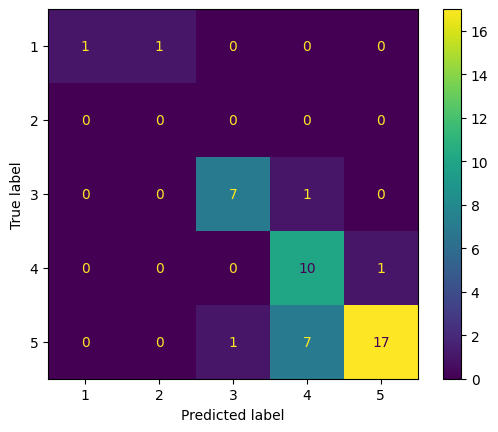

In [ ]:
dfSamp_Val_Real = DfValSamp ['RealVal']
dfSamp_Val_Pred = DfValSamp ['PredVal']

MCVActual_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Val_Real.index) # Inicializar con el mismo indice
for index, x in dfSamp_Val_Real.items(): # Iterar en el indice y valor
  if x >=0 and x < 0.2:
    MCVActual_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCVActual_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCVActual_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCVActual_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCVActual_Samp.loc[index, 'Categ'] = 5

# Convertir la columna a entero despues de poblarla
MCVActual_Samp['Categ'] = MCVActual_Samp['Categ'].astype(int)

MCVPred_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Val_Pred.index)
for index, x in dfSamp_Val_Pred.items():
  if x >=0 and x < 0.2:
    MCVPred_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCVPred_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCVPred_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCVPred_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCVPred_Samp.loc[index, 'Categ'] = 5

MCVPred_Samp['Categ'] = MCVPred_Samp['Categ'].astype(int)

# MCVActual_Samp y MCVPred_Samp deben tener el mismo número de filas que DfVal
Vconfusion_matrix = metrics.confusion_matrix(MCVActual_Samp['Categ'], MCVPred_Samp['Categ'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = Vconfusion_matrix, display_labels = [1,2,3,4,5])

cm_display.plot()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nReporte de clasificación:")
print(classification_report(MCVActual_Samp['Categ'], MCVPred_Samp['Categ'],zero_division=0))


Reporte de clasificación:
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.00      0.00      0.00         0
           3       0.88      0.88      0.88         8
           4       0.56      0.91      0.69        11
           5       0.94      0.68      0.79        25

    accuracy                           0.76        46
   macro avg       0.68      0.59      0.60        46
weighted avg       0.84      0.76      0.78        46



In [ ]:
from scipy.stats import wilcoxon

if len(dfSamp_Val_Real) != len(dfSamp_Val_Pred):
  print("Error: The lengths of dfSamp_Val_Real and dfSamp_Val_Pred are different.")
else:
  #Wilcoxon signed-rank
  #La prueba evalua si existe una diferencia significativo entre pares de prueba
  #Es una prueba no paramétrica, adecuada para cuando las diferencias no tienen una distribución normal
  #statistic, p_value = wilcoxon(dfSamp_Val_Real, dfSamp_Val_Pred)
  statistic, p_value = wilcoxon(MCVActual_Samp['Categ'],MCVPred_Samp['Categ'])

  print("Resultados de la prueba de rango con signo de Wilcoxon:")
  print(f"Estadístico W: {statistic}")
  print(f"Valor p: {p_value}")

  alpha = 0.05  # Nivel de significancia
  if p_value < alpha:
    print(f"El valor p ({p_value:.4f}) es menor que el nivel de significancia ({alpha}).")
    print("Se rechaza la hipótesis nula. Hay una diferencia significativa entre las medianas de dfSamp_Val_Real y dfSamp_Val_Pred.")
  else:
    print(f"El valor p ({p_value:.4f}) es mayor que o igual al nivel de significancia ({alpha}).")
    print("No se rechaza la hipótesis nula. No hay evidencia suficiente para concluir una diferencia significativa entre las medianas de dfSamp_Val_Real y dfSamp_Val_Pred.")



Resultados de la prueba de rango con signo de Wilcoxon:
Estadístico W: 16.5
Valor p: 0.10880943004054568
El valor p (0.1088) es mayor que o igual al nivel de significancia (0.05).
No se rechaza la hipótesis nula. No hay evidencia suficiente para concluir una diferencia significativa entre las medianas de dfSamp_Val_Real y dfSamp_Val_Pred.


In [ ]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(MCVActual_Samp['Categ'], MCVPred_Samp['Categ'])
print("Cohen's Kappa:", kappa)


Cohen's Kappa: 0.6390870185449358


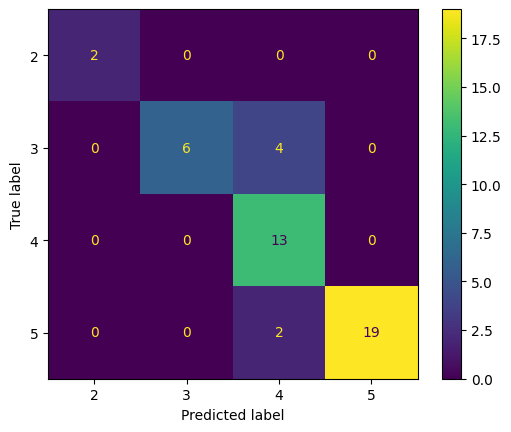

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

dfSamp_Act_Real = DfActSamp ['RealAct']
dfSamp_Act_Pred = DfActSamp ['PredAct']

MCActual_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Act_Real.index) # Initialize with the same index
for index, x in dfSamp_Act_Real.items(): # Iterate through index and value
  if x >=0 and x < 0.2:
    MCActual_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCActual_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCActual_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCActual_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCActual_Samp.loc[index, 'Categ'] = 5

# Convert the column to integer type after population
MCActual_Samp['Categ'] = MCActual_Samp['Categ'].astype(int)

MCPred_Samp = pd.DataFrame(columns=['Categ'], index=dfSamp_Act_Pred.index) # Initialize with the same index
for index, x in dfSamp_Act_Pred.items(): # Iterate through index and value
  if x >=0 and x < 0.2:
    MCPred_Samp.loc[index, 'Categ'] = 1
  elif x >= 0.2 and x < 0.4:
    MCPred_Samp.loc[index, 'Categ'] = 2
  elif x >= 0.4 and x < 0.6:
    MCPred_Samp.loc[index, 'Categ'] = 3
  elif x >= 0.6 and x < 0.8:
    MCPred_Samp.loc[index, 'Categ'] = 4
  elif x >= 0.8 and x <= 1:
    MCPred_Samp.loc[index, 'Categ'] = 5

# Convert the column to integer type after population
MCPred_Samp['Categ'] = MCPred_Samp['Categ'].astype(int)

# Now, both MCActual_Samp and MCPred_Samp should have the same number of rows as the original DfAct
confusion_matrix = metrics.confusion_matrix(MCActual_Samp['Categ'], MCPred_Samp['Categ'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [2,3,4,5]) # Update display labels

cm_display.plot()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nReporte de clasificación:")
print(classification_report(MCActual_Samp['Categ'], MCPred_Samp['Categ'],zero_division=0))


Reporte de clasificación:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         2
           3       1.00      0.60      0.75        10
           4       0.68      1.00      0.81        13
           5       1.00      0.90      0.95        21

    accuracy                           0.87        46
   macro avg       0.92      0.88      0.88        46
weighted avg       0.91      0.87      0.87        46



In [ ]:
kappa = cohen_kappa_score(MCActual_Samp['Categ'], MCPred_Samp['Categ'])
print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.8036984352773826
